In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("../data/clean_data_with_splits.csv")

In [5]:
#X = df["Class"]
#Y = df["Border"]
features = pd.read_csv("../data/extracted_features.csv")


In [10]:
cols = ['Asymmetry', 'Compactness', 'Convexity']
for col in cols:
    avg_val = features[col].mean()
    features.loc[features['2_3_lesions'] == True, col] = avg_val
features.to_csv('../data/extracted_features_mean.csv', index=False)

In [ ]:
#Since pairplot uses all columns, make a copy of df with just features columns

feature_cols = ["Asymmetry", "Compactness", "Convexity",
                "Multicolor", "Hue_Var", "Sat_Var", "Val_Var"]

df = features[feature_cols + ["Class"]].copy()

In [ ]:
#since pairplot only uses numeric values, make a new column label with numeric values and drop "Class"

df["label"] = df["Class"].astype(int)
df = df.drop(columns=["Class"])

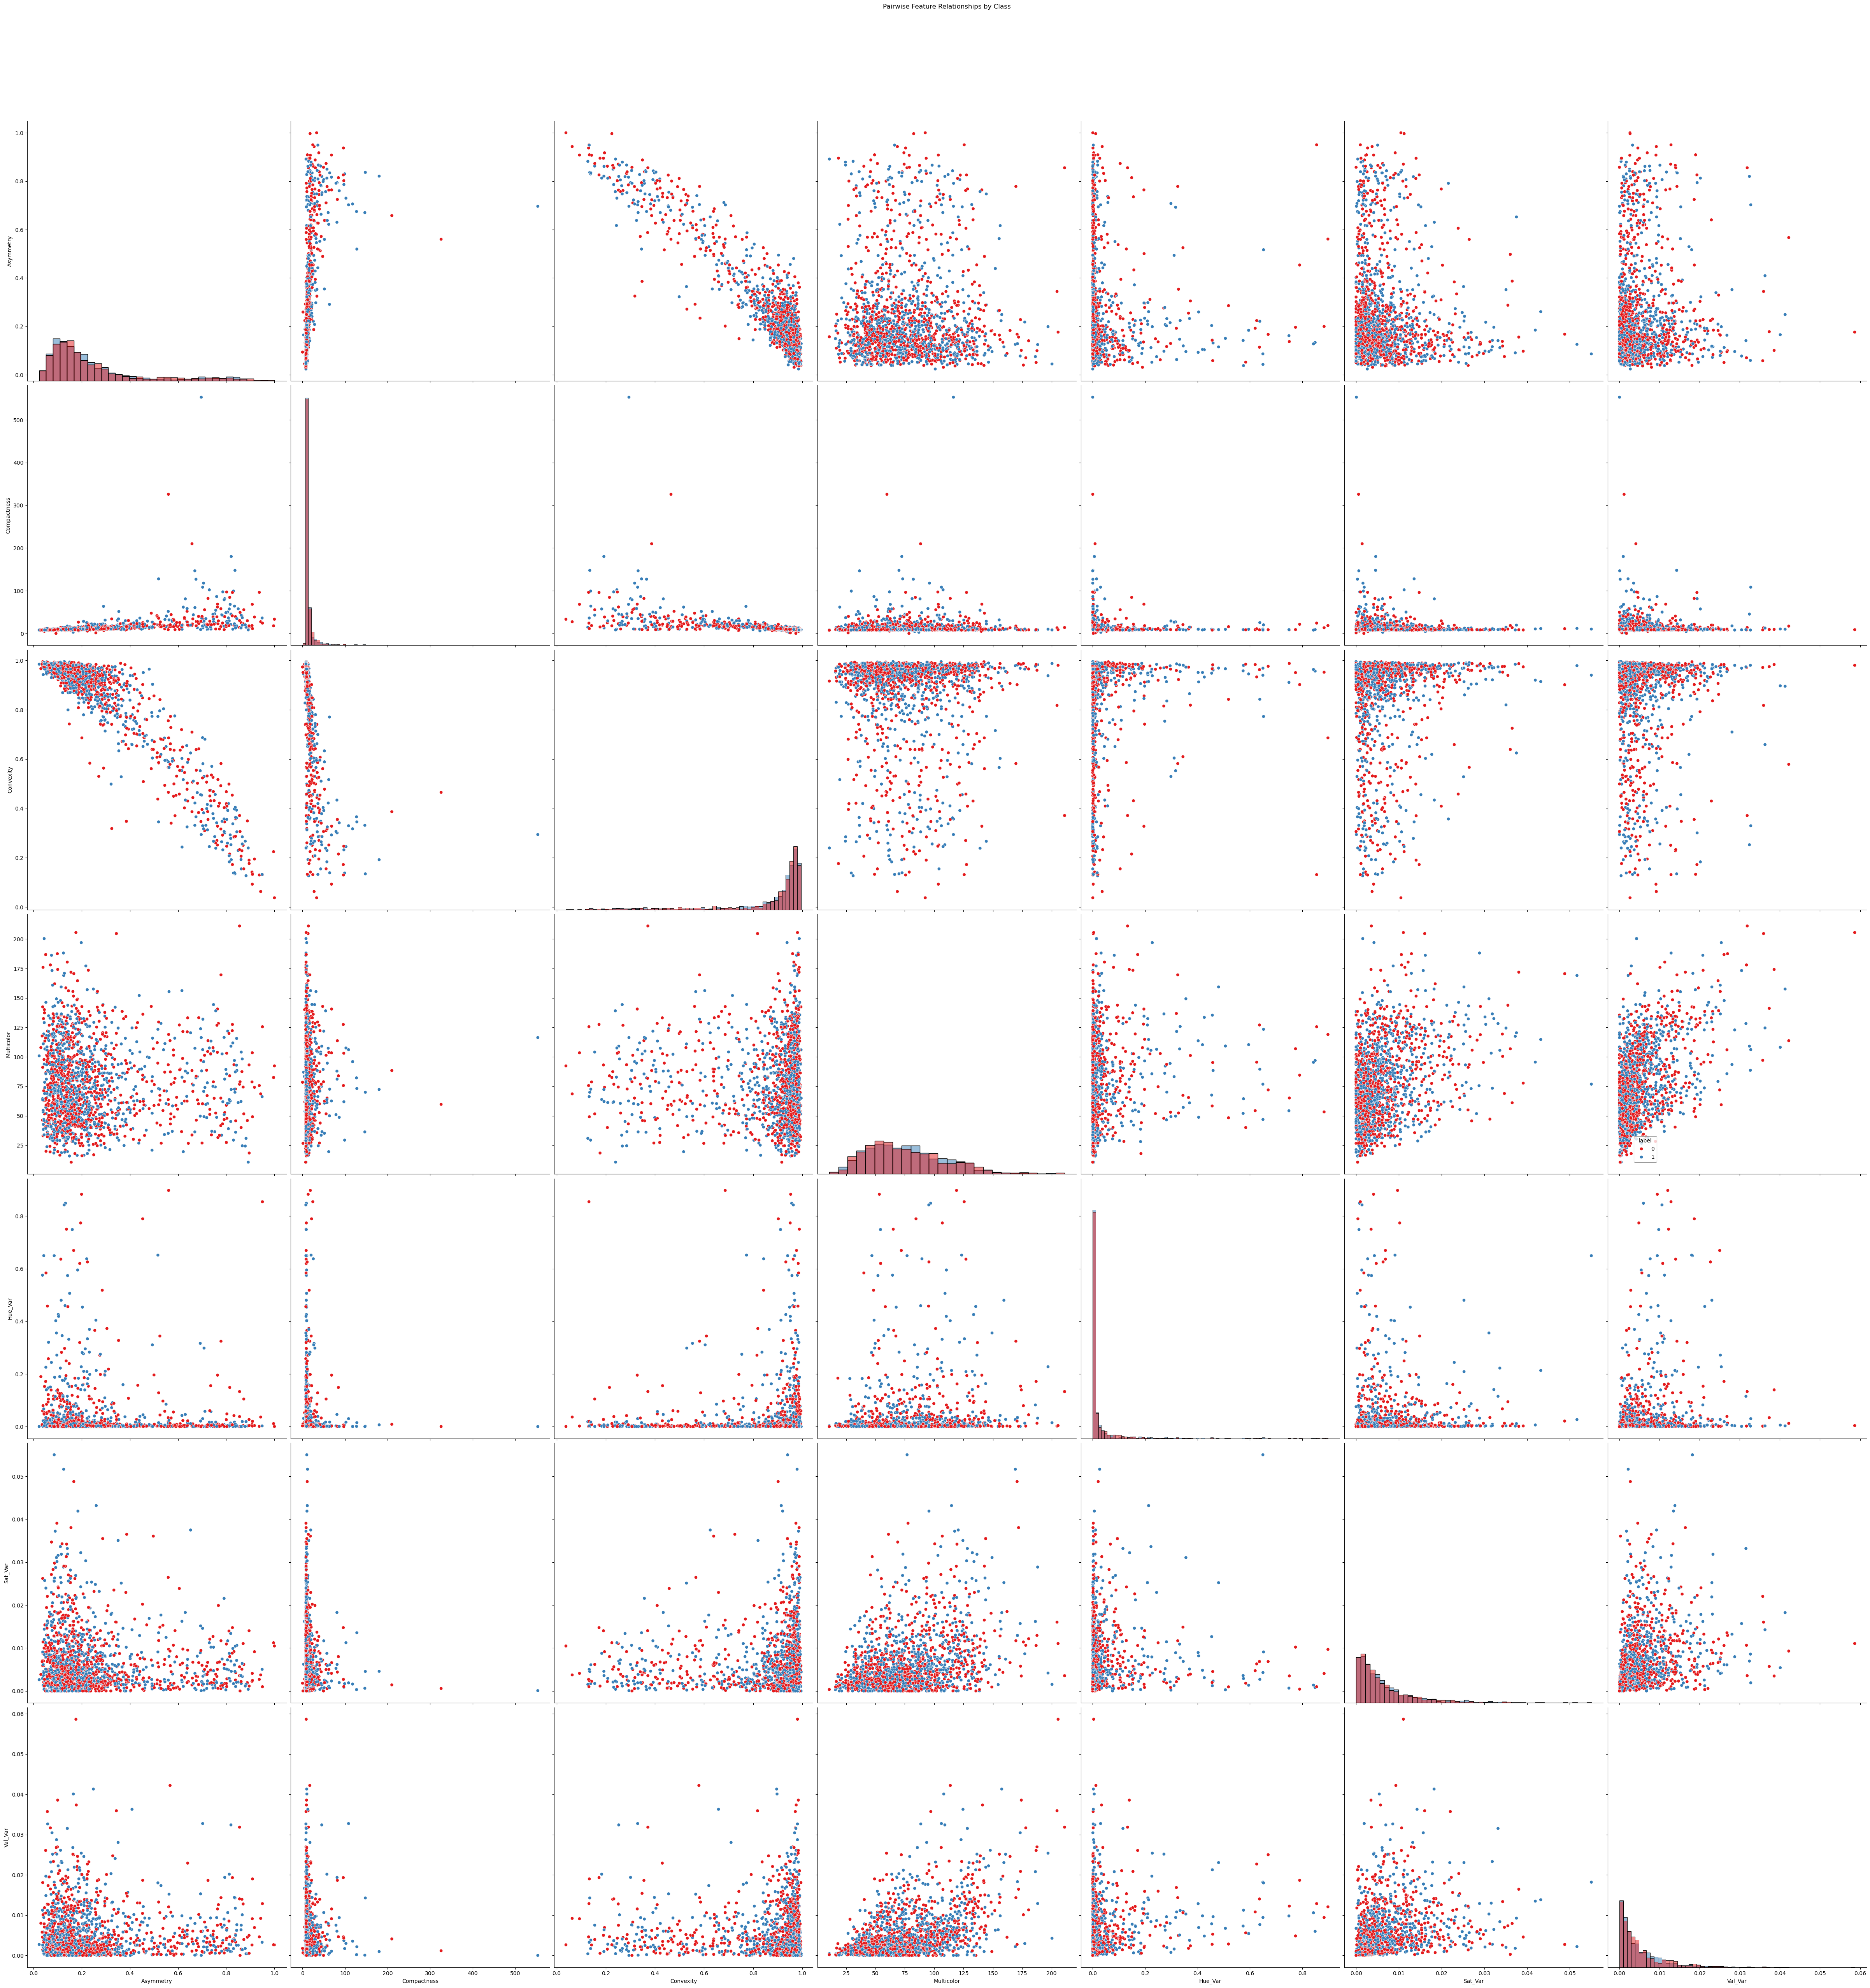

In [ ]:
g = sns.pairplot(df, hue='label', palette="Set1", height=7, diag_kind="hist")

g.fig.suptitle("Pairwise Feature Relationships by Class", y=1.05)

g._legend.set_bbox_to_anchor((0.86, 0.44))

g._legend.set_frame_on(True)
frame = g._legend.get_frame()
frame.set_edgecolor("gray")
frame.set_linewidth(0.8)
frame.set_facecolor("white")

# create a label saying red is malignant and blue is benign


plt.show()

This above plot shows strong overlap between melanoma and non-melanoma classes across most features. Some correlations exist (like asymmetry and convexity), but individual features do not clearly separate the classes. This tells us that classification requires combining features or considering non linear classifier.

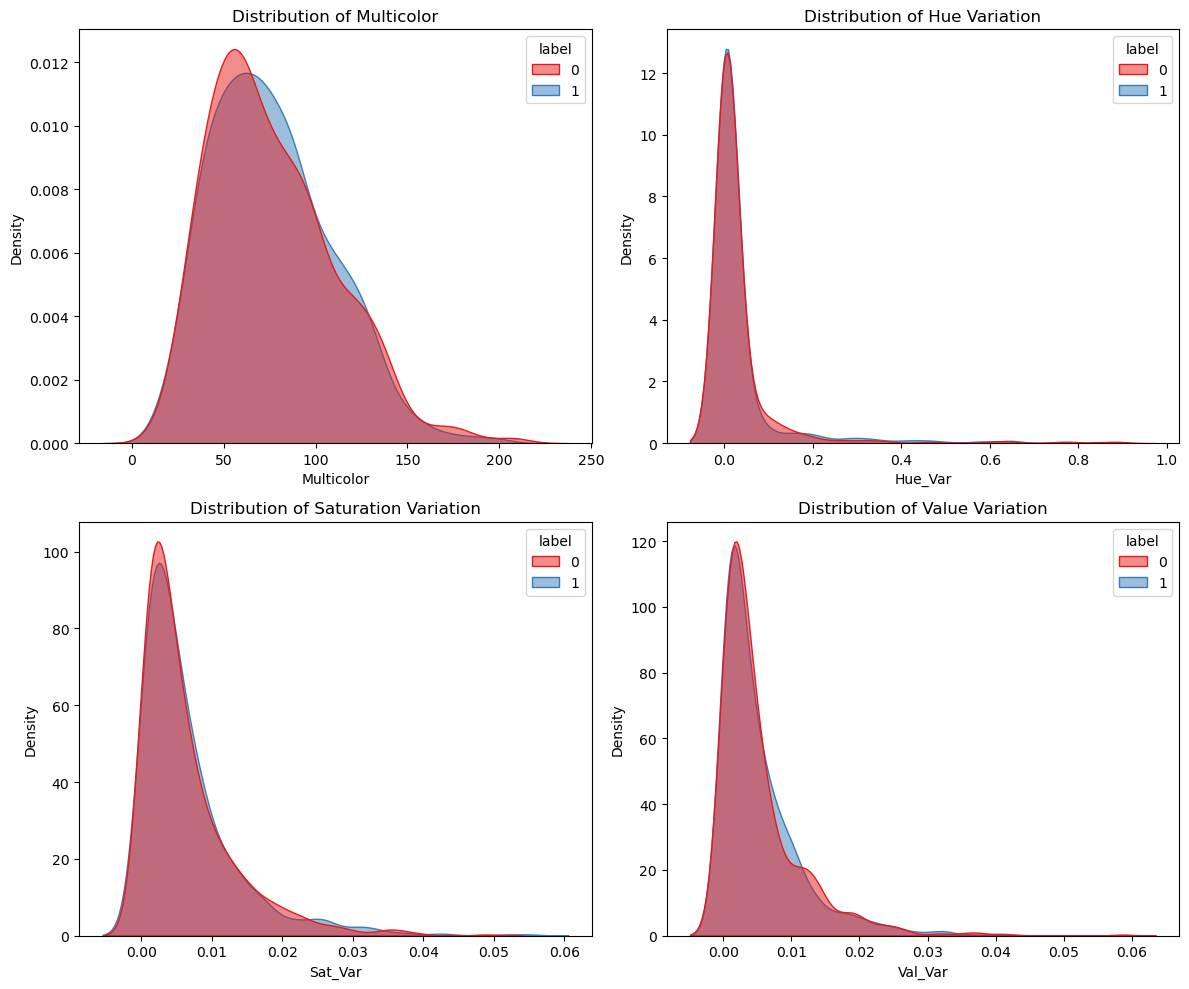

In [ ]:
#Density plots for color features

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.kdeplot(data=df, x="Multicolor", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Multicolor")
sns.kdeplot(data=df, x="Hue_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Hue Variation")
sns.kdeplot(data=df, x="Sat_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Saturation Variation")
sns.kdeplot(data=df, x="Val_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Value Variation")

plt.tight_layout()
plt.show()



In [ ]:
from sklearn.preprocessing import StandardScaler

# List of features I want to scale
color_features = ["Multicolor", "Hue_Var", "Sat_Var", "Val_Var"]
object = StandardScaler()

#Create a copy of df
df_scaled = df.copy()

# standardization 
df_scaled[color_features] = object.fit_transform(df[color_features])


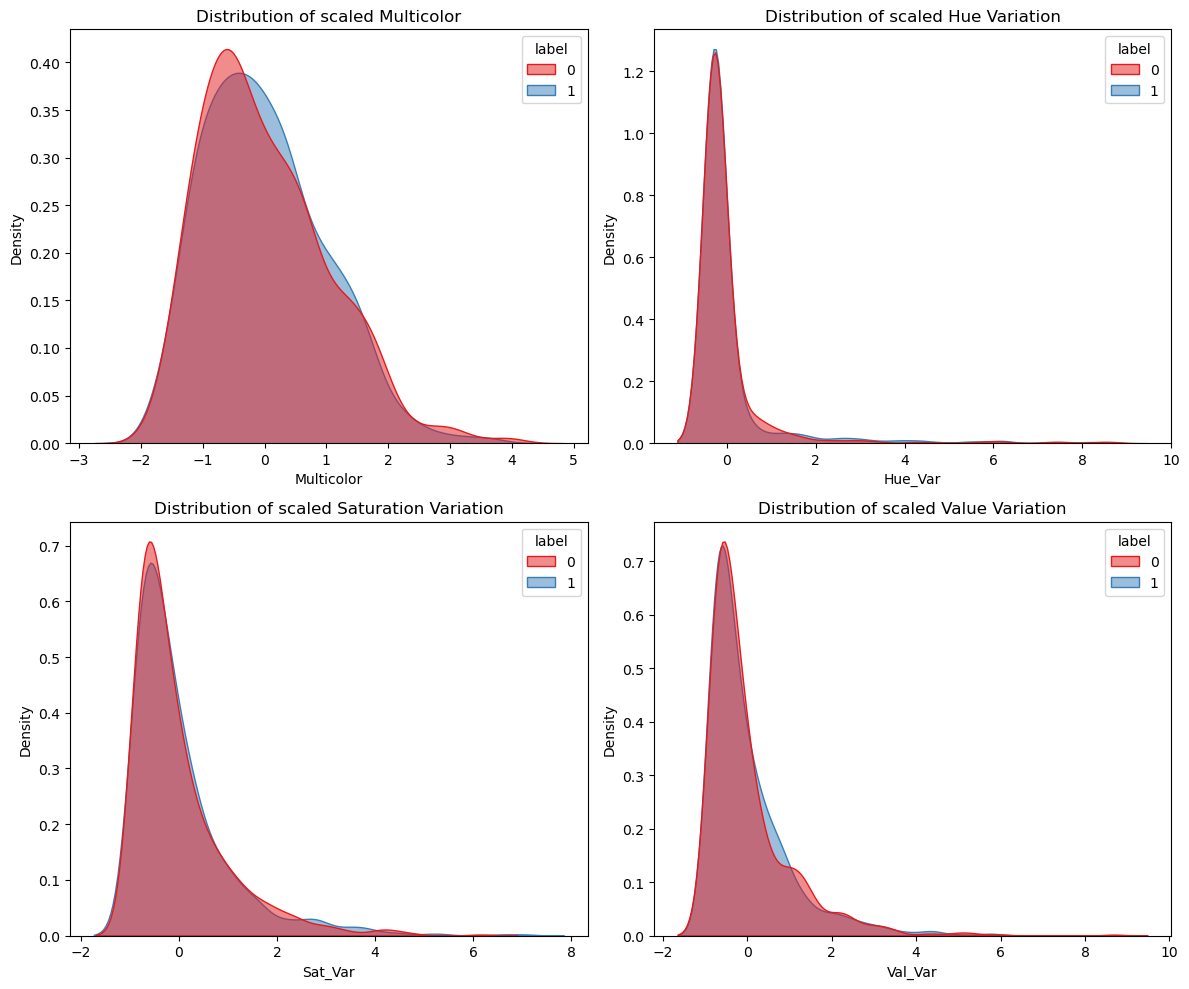

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.kdeplot(data=df_scaled, x="Multicolor", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of scaled Multicolor")
sns.kdeplot(data=df_scaled, x="Hue_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of scaled Hue Variation")
sns.kdeplot(data=df_scaled, x="Sat_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of scaled Saturation Variation")
sns.kdeplot(data=df_scaled, x="Val_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of scaled Value Variation")

plt.tight_layout()
plt.show()

Standardizing the features centered the distributions at zero but did not improve class separation. This reveals that the overlap is not a result of different units across features, but rather is inbuilt to the data itself.